In [1]:
# Cell 1 - Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Cell 2 - Load Dataset
df = pd.read_csv('../data/Reviews.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (568454, 10)

Column Names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

First 5 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
# Cell 3 - Basic Info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Score Distribution ===")
print(df['Score'].value_counts().sort_index())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB
None

=== Missing Values ===
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score

In [4]:
# Cell 4 - Data Cleaning
# Drop duplicates
df = df.drop_duplicates(subset=['UserId', 'ProfileName', 'Time', 'Text'])

# Drop rows with missing Summary
df = df.dropna(subset=['Summary', 'ProfileName'])

# Convert Time from Unix timestamp to readable date
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# Add helpfulness ratio column
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

print(f"Clean dataset shape: {df.shape}")
print(f"\nYear range: {df['Year'].min()} to {df['Year'].max()}")
print("\nCleaning complete!")

Clean dataset shape: (393914, 13)

Year range: 1999 to 2012

Cleaning complete!


In [5]:
# Cell 5 - Statistical Summary
print("=== Descriptive Statistics ===")
print(df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']].describe().round(2))

print(f"\n=== Key Insights ===")
print(f"Total unique products: {df['ProductId'].nunique()}")
print(f"Total unique reviewers: {df['UserId'].nunique()}")
print(f"Average rating: {df['Score'].mean():.2f} out of 5")
print(f"Most active year: {df['Year'].value_counts().idxmax()}")
print(f"Average review text length: {df['Text'].str.len().mean():.0f} characters")

=== Descriptive Statistics ===
           Score  HelpfulnessNumerator  HelpfulnessDenominator  \
count  393914.00             393914.00               393914.00   
mean        4.18                  1.73                    2.20   
std         1.31                  6.87                    7.53   
min         1.00                  0.00                    0.00   
25%         4.00                  0.00                    0.00   
50%         5.00                  0.00                    1.00   
75%         5.00                  2.00                    2.00   
max         5.00                866.00                  923.00   

       HelpfulnessRatio  
count         393914.00  
mean               0.42  
std                0.46  
min                0.00  
25%                0.00  
50%                0.00  
75%                1.00  
max                3.00  

=== Key Insights ===
Total unique products: 67623
Total unique reviewers: 256042
Average rating: 4.18 out of 5
Most active year: 2012
Avera

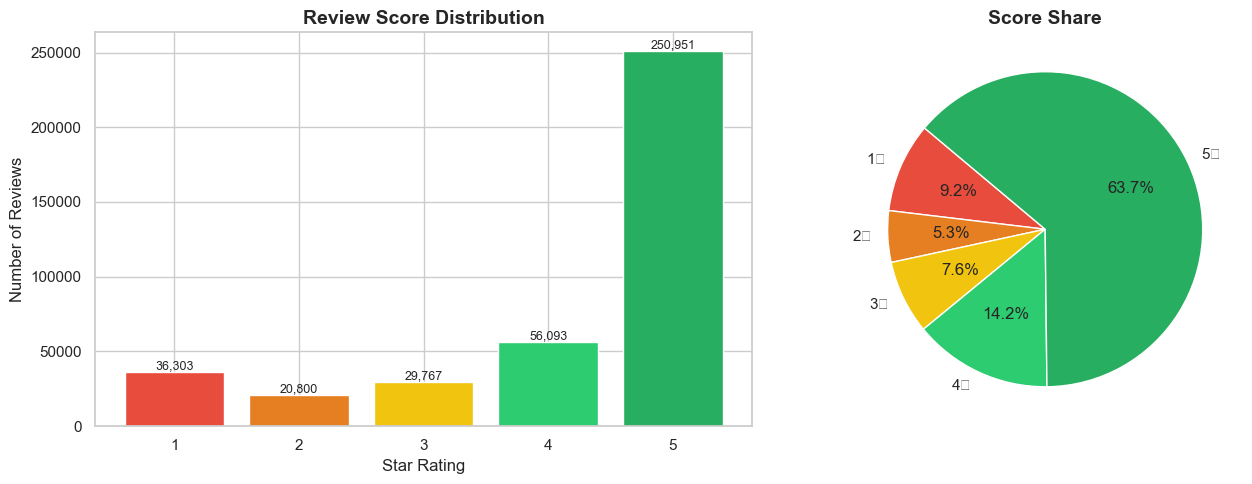

Chart saved to images/


In [6]:
# Cell 6 - Score Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
score_counts = df['Score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, 
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Review Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(score_counts.values):
    axes[0].text(i+1, v+2000, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(score_counts.values, labels=['1★','2★','3★','4★','5★'],
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Score Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

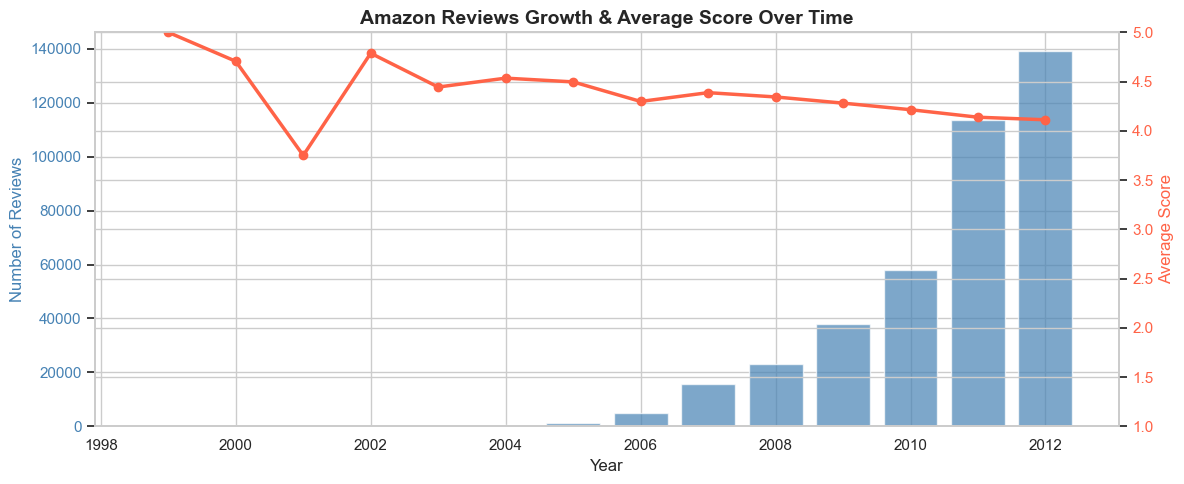

Chart saved!


In [7]:
# Cell 7 - Reviews Over Time
yearly = df.groupby('Year').agg(
    review_count=('Score', 'count'),
    avg_score=('Score', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(yearly['Year'], yearly['review_count'], color='steelblue', alpha=0.7, label='Review Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Reviews', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['avg_score'], color='tomato', marker='o', linewidth=2.5, label='Avg Score')
ax2.set_ylabel('Average Score', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(1, 5)

plt.title('Amazon Reviews Growth & Average Score Over Time', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('../images/reviews_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

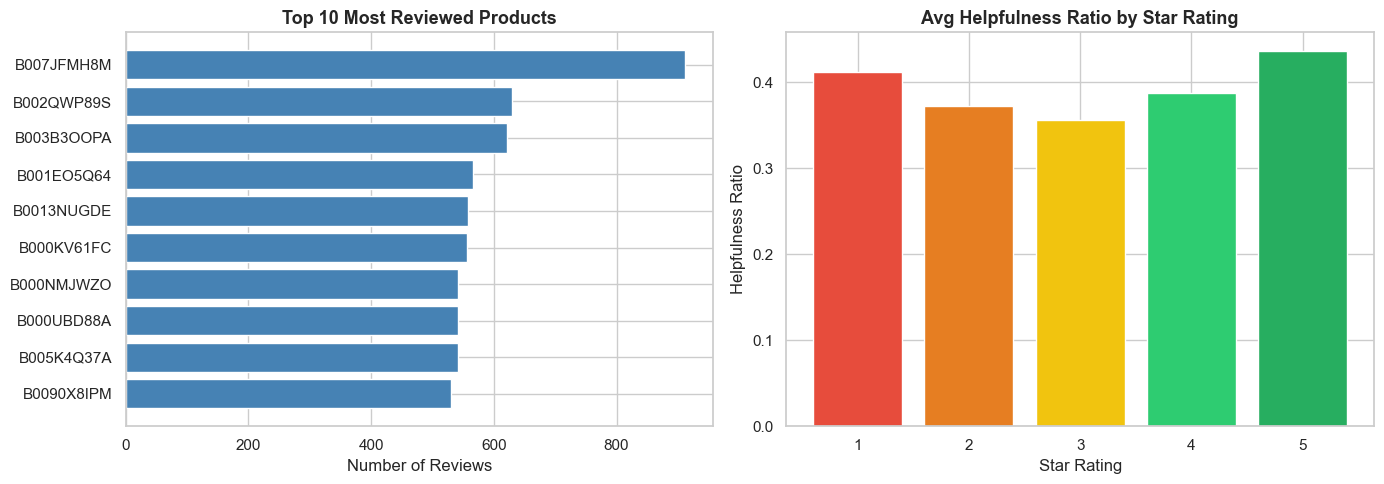

Chart saved!


In [8]:
# Cell 8 - Top Products & Helpfulness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 most reviewed products
top_products = df['ProductId'].value_counts().head(10)
axes[0].barh(top_products.index[::-1], top_products.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Most Reviewed Products', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')

# Average score per star - helpfulness ratio
help_by_score = df.groupby('Score')['HelpfulnessRatio'].mean()
axes[1].bar(help_by_score.index, help_by_score.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[1].set_title('Avg Helpfulness Ratio by Star Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Helpfulness Ratio')

plt.tight_layout()
plt.savefig('../images/products_helpfulness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Cell 9 - Save clean data and print EDA summary
df.to_csv('../data/Reviews_clean.csv', index=False)

print("=" * 45)
print("   EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 45)
print(f"  Total clean reviews    : {len(df):,}")
print(f"  Unique products        : {df['ProductId'].nunique():,}")
print(f"  Unique reviewers       : {df['UserId'].nunique():,}")
print(f"  Average star rating    : {df['Score'].mean():.2f} / 5")
print(f"  Date range             : {df['Year'].min()} – {df['Year'].max()}")
print(f"  Avg review length      : {df['Text'].str.len().mean():.0f} chars")
print(f"  5-star review share    : {(df['Score']==5).mean()*100:.1f}%")
print(f"  Clean data saved to    : data/Reviews_clean.csv")
print("=" * 45)

   EDA COMPLETE — KEY FINDINGS SUMMARY
  Total clean reviews    : 393,914
  Unique products        : 67,623
  Unique reviewers       : 256,042
  Average star rating    : 4.18 / 5
  Date range             : 1999 – 2012
  Avg review length      : 434 chars
  5-star review share    : 63.7%
  Clean data saved to    : data/Reviews_clean.csv
